这是一个MLP

In [124]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [125]:
words=open('names.txt','r').read().splitlines()


In [126]:
#依旧遍历然后建立词表stoi,itos
chars=sorted(set(''.join(words)))#先建立一个里面有的字符的排序表chars
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}


# 开始构建主体

先梳理清楚，接下来开始构建的是MLP的主体，前向传播部分。MLP的组成原理从逻辑上来说，就是一次看三个字符，这就是我们要达到的效果，比方说abcd里面根据前面三个来预测第四个是啥。之前我们使用的一个的。然后因为用三个如果还用之前那种概率表形式的话参数会太多了，你想27*27*27可能性太多了，更别说后面还要乘以输入，表大的你算的绝望。所以改用emb的方式，即先把某个词嵌入2维向量，比方说a我就用(1,2)来表示（具体用什么表示是模型自己训练出来的，我们一开始初始化一个随机的就行。）然后再把这个玩意和参数W相乘。得到的输出再softmax一下，最后输出一个向量，即27维的，每个维度对应那个维度的概率是多少。然后损失函数就根据xs和ys的错位，也就是ys是一个字母，xs是三个字母嘛，我们依旧用之前的似然值作为损失函数，也就是把当时那前面几个xs的输出预测的那个ys给softmax，再log，然后来求平均概率的，再加一个正则化就行

## 一些对我难点：
首先拼接维度那里，我要用到的一些函数我还不是很熟悉。比如cat之类的，torch的功能实在是太多了，还有一些维度上面的规定我也不是很熟悉。后面的部分和之前的很相似我觉得应该还好，就是前期的处理我需要注意一下。以及把看的词块写灵活用的block_size等，先写着看吧。

## 目标：超越2.17这个损失值，然后采样看看。调参玩耍play
调整的清单有：
1.嵌入层维度
2.隐藏层大小和层数
3.学习率的一些手法调整
4.blocksize
5.
## 修改日志
1.先构建了完整的第一版本框架，
2.有了分批训练,找了一下最合适的lr大概是多少
3.有了训练集，验证集，测试集


In [127]:

def bulid_words(words):
    block_size=4
    X,Y=[],[]
    for w in words:
        #print(w)
        
        context=[0]*block_size
        for ch in w+'.':
            
            #接下来要做的是：先打印一次context，这是我们前三个观测的值，放到输入xs里
            # 然后可以打印其下一个值，并把下一个词放到ys里。再之后移动context即可
            ix=stoi[ch]
            Y.append(ix)
            X.append(context)
            #print(''.join(itos[i] for i in context),'--->',itos[ix])
            context=context[1:]+[ix]
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y

#分成训练集，验证集，测试集，比例大概是8:1:1
#先分割好原数据集
n1=int(0.8*len(words))
n2=int(0.9*len(words))
import random
random.seed(42)
random.shuffle(words)
trX,trY=bulid_words(words[:n1])
devX,devY=bulid_words(words[n1:n2])
tesX,tesY=bulid_words(words[n2:])

trY.shape
        

torch.Size([182625])

In [128]:
block_size=4
dim=10
C=torch.randn((27,dim))

#处理C[X]和W的矛盾有两种办法
#用unbind➕cat，一个拆一个拼，unbind原理是先把他们按照你给定的维度拆，拆成很多小块，cat是拼接

#直接view，最轮椅，pytorch里最方便的。有点类似数据结构里面
#那个线性结构和储存方式，即存在内存里其实就一维，只是读取方式不同

g=torch.Generator().manual_seed(5438)
#所以接下来就是改一下规模，因为我们想要他们能成只能转化为矩阵
W1=torch.randn((block_size*dim,500),generator=g)
b1=torch.randn(500,generator=g)
#torch.cat(torch.unbind(emd,1),1).shape

#这一层（隐藏层）的前向传播（这是理论草稿，后面会注释掉）：
#hide=torch.tanh(emd.view(-1,6)@W1+b1)#这里用-1表示第一个维度你自适应，这样后面改参数不是硬编码

#晚上在写完后面的
#接下来开始构建第二层，根据之前输入规定输出层数就好,规定好参数规模
W2=torch.randn((500,27),generator=g)
b2=torch.randn((27),generator=g)





In [129]:
#前向传播前，用交叉熵函数写法，不用的之前已经试过了就没什么必要了。记得设置requires_grad
paraments=[C,W1,W2,b1,b2]
for p in paraments:
    p.requires_grad=True


In [139]:
echo=100090
import matplotlib.pyplot as plt
# ir=torch.linspace(-3,0,1000)
# lrs=10**ir
stepi = []
lossi=[]
# lri=[]
for i in range(echo):
    ix=torch.randint(0,trX.shape[0],(32,))
    emd=C[trX[ix]]
    hide=torch.tanh(emd.view(-1,block_size*dim)@W1+b1)
    logits=hide@W2+b2
    loss=F.cross_entropy(logits,trY[ix])
    #print(loss.item())
    for p in paraments:
        p.grad=None
    loss.backward()

    #lr=lrs[i]
    
    if i<=20000:
        lr=0.1
    elif i<=40000: 
        lr=0.05
    else :
        lr=0.01
    if i % 100 == 0:
        stepi.append(i)
        lossi.append(loss.item())

    for p in paraments:
        p.data+=-lr*p.grad
    #lri.append(ir[i])
    #lossi.append(loss.item())



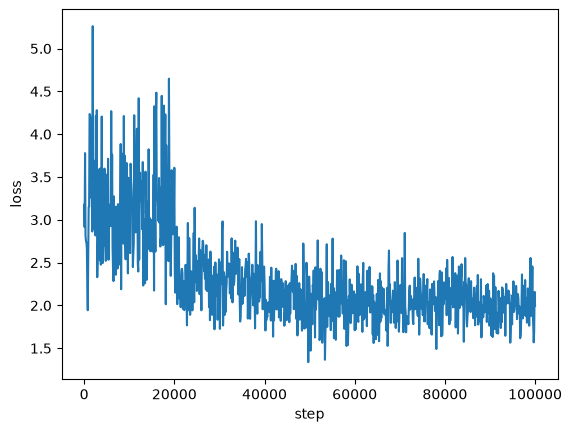

In [140]:
plt.plot(stepi, lossi)
plt.xlabel('step')
plt.ylabel('loss')
plt.show()

In [141]:
emd=C[devX]
hide=torch.tanh(emd.view(-1,40)@W1+b1)
logits=hide@W2+b2
loss=F.cross_entropy(logits,devY)
loss

tensor(2.1570, grad_fn=<NllLossBackward0>)

tensor(2.1570, grad_fn=<NllLossBackward0>)
挑战成功，哈哈，突破了2.17这个值。